## 奇性嵌入格林函数算法：求解一维Poisson方程

## 1. 问题描述(1D Poisson Equations)

考虑一维区间$[0,1]$上的Poisson方程：

$$
\begin{aligned}
- u''(x) = f(x), \ \ \ \textnormal{for}\ x\in\Omega = (0,1), \\
u(x) = 0, &\ \ \ \ \textnormal{for}\ x\ \textnormal{on}\ \partial\Omega
\end{aligned} 
$$

其对应的格林函数，对任一固定$\bm{y}\in\Omega$，满足方程：
$$
\begin{aligned}
-\partial_{xx} G(x,y) = 0, \ \ \ &\ \textnormal{for}\ x\in\Omega\setminus\Gamma, \\
			\llbracket G(x,y) \rrbracket = 0,\ \ \ \llbracket \partial_x G(x,y) \rrbracket = -1, \ \ \ &\ \textnormal{for}\ x\in\Gamma = \{ x \,|\, x=y\},\\
			G(x,y) = 0, \ \ \ &\ \textnormal{for}\ x\in\partial\Omega.
\end{aligned}
$$
其中，$\llbracket G(x,y) \rrbracket = G(x^+,y) - G(x^-,y)=0$，表示$G(x,y)$在界面$\Gamma$处函数值连续，$\llbracket \partial_x G(x,y) \rrbracket = \partial_x G(x^+,y) - \partial_x G(x^-,y)=-1$，表示导数值存在跳量。

## 2. 升维嵌入学习方法

通过引入辅助变量$\varphi(\bm{x},\bm{y})=|x-y|$，考虑如下形式的解
$$
G(\bm{x},\bm{y}) = \widehat{G}( \bm{x}, \bm{y},  \varphi( \bm{x}, \bm{y} )) 
$$
并将其代入方程推导得出，对任一固定$y\in\Omega$，
$$
\begin{aligned}
-(\partial_{xx} + \partial_{zz}) \widehat{G}(x,y,\varphi(x,y)) - 2 \textnormal{sgn}(x-y) \partial_{x z}\widehat{G}(x,y,\varphi(x,y)) = 0, \ &\ \ \ \mathrm{for}\ x \in \Omega\setminus\Gamma,\\
			\displaystyle -2\partial_{z}\widehat{G}(x,y,\varphi(x,y)) = 1, \ &\ \ \ \textnormal{for}\ x\in \Gamma=\{ x \,|\, x = y \},\\
			\widehat{G} (x, y, \varphi( x, y) ) = 0, \ &\ \ \ \mathrm{for}\ x \in \partial\Omega.
\end{aligned}
$$

### 函数逼近
由于辅助变量的引入导致函数自变量维数的升高，因此需采用无惧“维数灾难”的函数逼近工具，即人工神经网络

在此，我们使用一个全连接网络（fully-connected neural network）来参数化未知函数，其中神经网络的待定参数用 
$\theta$表示，即

$$
\widehat{G}(x,y,\varphi(x,y)) \approx \widehat{G}_{NN}(x,y,\varphi(x,y)).
$$

损失函数

通过方程的残量来定义格林函数在光滑、奇性、边界处的损失函数
$$
\displaystyle  L_{\textnormal{Reglr}} (\theta) = \frac{1}{M} \sum_{m=1}^M \bigg( \frac{1}{N_{\textnormal{R}}} \sum_{n=1}^{N_{\textnormal{R}}} 
            \bigg| \Big( \partial_{xx} + 2\textnormal{sgn}(x-y)\partial_{xz}  + \partial_{zz} \Big)\widehat{G}( x_n^{\Omega}, y_m, \varphi( x_n^{\Omega}, y_m ) ;\theta) \bigg|^2 \bigg), \\[0.3cm]
            \displaystyle L_{\textnormal{Snglr}}^{d\geq 2} (\theta) = \frac{1}{M} \sum_{m=1}^M \left( \big| 2\partial_z\widehat{G}( y_m, y_m, \varphi(y_m, y_m);\theta) + 1 \big|^2 \right), \\
            \displaystyle L_{\textnormal{Bndry}} (\theta) =  \frac{1}{M} \sum_{m=1}^M \bigg( \frac{1}{N_{\textnormal{B}}} \sum_{n=1}^{N_{\textnormal{B}}} \big|  \widehat{G}( x_n^{\partial \Omega}, y_m, \varphi( x_n^{\partial\Omega}, y_m ) ;\theta) \big|^2 \bigg),

$$


## 3.编程求解

### 3-1. 准备工作 - 调用函数库

In [19]:
import torch
import torch.nn as nn
import numpy as np
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import time
import datetime
import argparse 

from torch import optim, autograd
from torch.utils.data import DataLoader, TensorDataset
from matplotlib import pyplot as plt

# matlab to tensor and vice versa
from scipy.io import loadmat
import numpy as np
import scipy.io as io

# load data from two datasets within the same loop
from itertools import cycle

print("pytorch version", torch.__version__, "\n")
torch.set_default_dtype(torch.float64)

pytorch version 1.11.0+cpu 



### 3-1. 准备工作 - 全连接神经网络

In [3]:
class FcBlock(nn.Module):
    """ 
        dim_in  -- dimension of each block's input data
        width   -- number of nodes in each block's hidden layer
        dim_out -- dimension of each block's output data (not the dimension of final output)  
    """
    
    def __init__(self, dim_in, width, dim_out):
        super(FcBlock, self).__init__()

        # set parameters
        self.dim_in = dim_in
        self.width = width
        self.dim_out = dim_out

        # create linear layers
        self.Linear1 = nn.Linear(dim_in, width)
        self.Linear2 = nn.Linear(width, dim_out)  
        # choose activation function = Tanh
        self.activation = nn.Tanh()      

    def forward(self, x):
        
        return self.activation(self.Linear2(self.activation(self.Linear1(x))))


class FcNet(nn.Module):
    """ 
        dim_in  -- dimension of each block's input data
        width   -- number of nodes in each block's hidden layer
        dim_out -- dimension of final output data   
    """

    def __init__(self, dim_in, width, dim_out, depth):
        super(FcNet, self).__init__()

        # set parameters
        self.dim_in = dim_in
        self.width = width
        self.dim_out = dim_out
        self.depth = depth

        # creat a list for holding all blocks/layers
        self.stack = nn.ModuleList()
                
        # input layer       
        self.stack.append(nn.Linear(dim_in, width))
        # add hidden blocks
        for i in range(depth):
            self.stack.append(FcBlock(width, width, width))        
        # output layer
        self.stack.append(nn.Linear(width, dim_out))  
        
    def forward(self, x):
        
        for layer in self.stack:
            x = layer(x)

        return x

    def Xavier_initi(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight.data)
                if m.bias is not None:
                    m.bias.data.zero_()  

## 3-1. 准备工作 - 训练和测试数据集

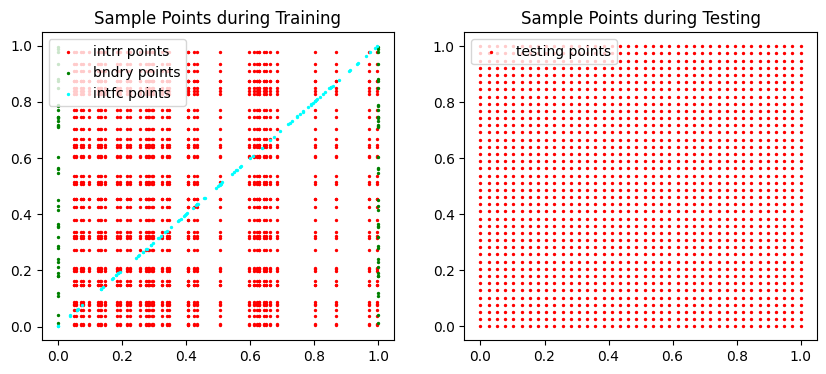

In [134]:
# computational domain
x_min, x_max = 0, 1
y_min, y_max = 0, 1

# number of collocation points for each part
traindata_size_intrr_x = 40
traindata_size_intrr_y = 40
traindata_size_bndry_x = 2 
traindata_size_intfc_x = 100

# generate testing points over the entire domain
x = torch.linspace(0, 1, steps=traindata_size_intrr_x)
y = torch.linspace(0, 1, steps=traindata_size_intrr_y)
X, Y = torch.meshgrid(x, y)
testdata = torch.squeeze(torch.stack([X.reshape(1,traindata_size_intrr_x*traindata_size_intrr_y), Y.reshape(1,traindata_size_intrr_x*traindata_size_intrr_y)], dim=-1))

# generate training points for each part
def SmpPts_Interior_Line1D(traindata_size_intrr_x, traindata_size_intrr_y):
    IntrrPts_x = torch.rand(traindata_size_intrr_x,1) 
    IntrrPts_y = torch.rand(traindata_size_intrr_y,1) 
    # generate (x,y)-pairs
    IntrrPts_x_Reshape =  IntrrPts_x.repeat(traindata_size_intrr_y, 1)
    IntrrPts_y_Reshape = torch.reshape( IntrrPts_y.repeat(1, traindata_size_intrr_x), (traindata_size_intrr_x*traindata_size_intrr_y, 1) )

    return torch.cat((IntrrPts_x_Reshape, IntrrPts_y_Reshape),1)

def SmpPts_Boundary_Line1D(traindata_size_bndry_x, traindata_size_intrr_y): 
    BndryPts_x = torch.tensor([[0], [1]])
    IntrrPts_y = torch.rand(traindata_size_intrr_y,1)
    BndryPts_x_Reshape = BndryPts_x.repeat(traindata_size_intrr_y,1)
    IntrrPts_y_Reshape = torch.reshape(IntrrPts_y.repeat(1,traindata_size_bndry_x), (traindata_size_bndry_x*traindata_size_intrr_y,1))
    
    return torch.cat((BndryPts_x_Reshape,IntrrPts_y_Reshape),1)

def SmpPts_Intfc_Line1D(traindata_size_intfc_x):
    Intfc_x = torch.rand(traindata_size_intfc_x,1)
    
    return Intfc_x.repeat(1,2)

smppts_intrr = SmpPts_Interior_Line1D(traindata_size_intrr_x, traindata_size_intrr_y)
smppts_bndry = SmpPts_Boundary_Line1D(traindata_size_bndry_x, traindata_size_intrr_y)
smppts_intfc = SmpPts_Intfc_Line1D(traindata_size_intfc_x)

fig = plt.figure(figsize=(10, 4), dpi= 100)
plt.subplot(1, 2, 1)
plt.scatter(smppts_intrr[:,0], smppts_intrr[:,1], c = 'red', label = 'intrr points', s=2)
plt.scatter(smppts_bndry[:,0], smppts_bndry[:,1], c = 'green', label = 'bndry points', s=2)
plt.scatter(smppts_intfc[:,0], smppts_intfc[:,1], c = 'cyan', label = 'intfc points', s=2)
plt.title('Sample Points during Training')
plt.legend(loc = 'upper left')

plt.subplot(1, 2, 2)
plt.scatter(testdata[:,0], testdata[:,1], c = 'red', label = 'testing points', s=2)
plt.title('Sample Points during Testing')
plt.legend(loc = 'upper left')
plt.show()

## 3-1. 准备工作 - 升维函数在样本点处的值

In [135]:
# define auxiliary variable
def augmented_variable(x, y):
    return torch.abs(x-y)

# append the value of auxiliary variable for each input data point
smppts_intrr = torch.cat([smppts_intrr, augmented_variable(smppts_intrr[:,0], smppts_intrr[:,1]).reshape(-1,1)], dim=1)
smppts_bndry = torch.cat([smppts_bndry, augmented_variable(smppts_bndry[:,0], smppts_bndry[:,1]).reshape(-1,1)], dim=1)
smppts_intfc = torch.cat([smppts_intfc, augmented_variable(smppts_intfc[:,0], smppts_intfc[:,1]).reshape(-1,1)], dim=1)
smppts_test = torch.cat([testdata, augmented_variable(testdata[:,0], testdata[:,1]).reshape(-1,1)], dim=1)

# exact solution 
def Green_Exact_Line1D(x, y):
    return x * (1-y) * (x<=y) + y * (1-x) * (x>y)

# load train data in mini-batches
batch_num = 4
batchsize = traindata_size_intrr_x * traindata_size_intrr_y // batch_num

dataset_intrr = TensorDataset(smppts_intrr)
dataset_bndry = TensorDataset(smppts_bndry)
dataset_intfc = TensorDataset(smppts_intfc)
dataloader_intrr= DataLoader(dataset_intrr, batch_size=batchsize, shuffle=True)
dataloader_bndry= DataLoader(dataset_bndry, batch_size=batchsize, shuffle=True)
dataloader_intfc= DataLoader(dataset_intfc, batch_size=batchsize, shuffle=True)

## 3-2. 网络训练

Done in 0:01:36.879836 !


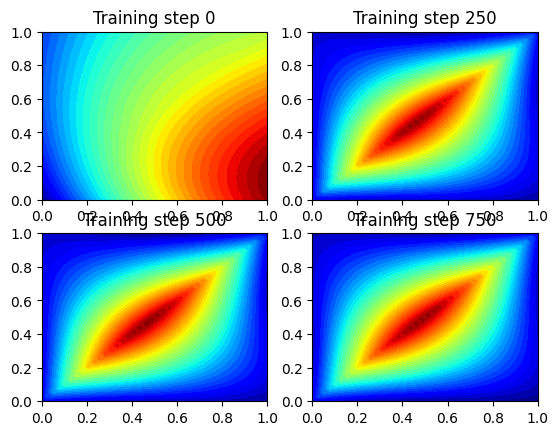

In [136]:
# penalty coefficient
beta_bndry = beta_intfc = 400
# for decay of learning rate
milestones = [500,650]

# create model
model = FcNet(3, 40, 1, 2)
model.Xavier_initi()

# create optimizer and learning rate schedular
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2, betas=(0.9, 0.999), eps=1e-08, weight_decay=0.01, amsgrad=False)
schedular = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones, gamma=0.1)

since = time.time()

for i in range(751):
    
    # get mini-batches
    for _, ( (data_intrr,), (data_bndry,), (data_intfc,) ) in \
        enumerate(zip(dataloader_intrr, cycle(dataloader_bndry), cycle(dataloader_intfc)) ):
        
        # enable computing gradients through autograd
        data_intrr.requires_grad = True
        data_bndry.requires_grad = True
        data_intfc.requires_grad = True
        
        # forward pass 
        G_NN_intrr = model(data_intrr)
        G_NN_bndry = model(data_bndry)
        G_NN_intfc = model(data_intfc)
        
        # zero parameter gradients and then compute NN prediction of the derivatives 
        model.zero_grad()
        Gx_NN_intrr = torch.autograd.grad(outputs=G_NN_intrr, inputs=data_intrr, grad_outputs=torch.ones_like(G_NN_intrr), retain_graph=True, create_graph=True, only_inputs=True)[0][:,[0]]
        Gz_NN_intrr = torch.autograd.grad(outputs=G_NN_intrr, inputs=data_intrr, grad_outputs=torch.ones_like(G_NN_intrr), retain_graph=True, create_graph=True, only_inputs=True)[0][:,[2]]
        Gz_NN_intfc = torch.autograd.grad(outputs=G_NN_intfc, inputs=data_intfc, grad_outputs=torch.ones_like(G_NN_intfc),retain_graph=True, create_graph=True, only_inputs=True)[0][:,[2]]
        
        # compute second-order derivatives
        Gxx_NN_intrr = torch.autograd.grad(outputs=Gx_NN_intrr, inputs=data_intrr, grad_outputs=torch.ones_like(Gx_NN_intrr), retain_graph=True, create_graph=True, only_inputs=True)[0][:,[0]]
        Gxz_NN_intrr = torch.autograd.grad(outputs=Gx_NN_intrr, inputs=data_intrr, grad_outputs=torch.ones_like(Gx_NN_intrr), retain_graph=True, create_graph=True, only_inputs=True)[0][:,[2]]
        Gzz_NN_intrr = torch.autograd.grad(outputs=Gz_NN_intrr, inputs=data_intrr, grad_outputs=torch.ones_like(Gz_NN_intrr), retain_graph=True, create_graph=True, only_inputs=True)[0][:,[2]]
        
        # derivative of the augmented variable
        
        loss_intrr = torch.mean(torch.pow(Gxx_NN_intrr + Gzz_NN_intrr + 2 * ((data_intrr[:,[0]]>data_intrr[:,[1]]) * Gxz_NN_intrr - (data_intrr[:,[0]]<data_intrr[:,[1]]) * Gxz_NN_intrr), 2))
        loss_bndry = torch.mean(torch.pow(G_NN_bndry, 2))
        loss_intfc = torch.mean(torch.pow(2 * Gz_NN_intfc + 1, 2))
        
        loss_minibatch = loss_intrr + beta_bndry * loss_bndry + beta_intfc * loss_intfc
        
        #zero parameter gradients
        optimizer.zero_grad()
        # backpropagation
        loss_minibatch.backward()
        # network parameter update
        optimizer.step()
        
        # plot the result as training progresses
        list_of_plots = []
        plt.rcdefaults()

        if i % 250 == 0: 
            ax = plt.subplot(2, 2, i // 250 + 1)
        
            G_test = model(smppts_test).detach()
            G_test = G_test.reshape(traindata_size_intrr_x, traindata_size_intrr_y)    

            ax.contourf(X, Y, G_test, 40, cmap = 'jet')        
            ax.set_title(f"Training step {i}")
        
            list_of_plots.append(ax)
    
time_elapsed = time.time() - since
print('Done in {}'.format(str(datetime.timedelta(seconds=time_elapsed))), '!')

## 3-3. 展示计算结果

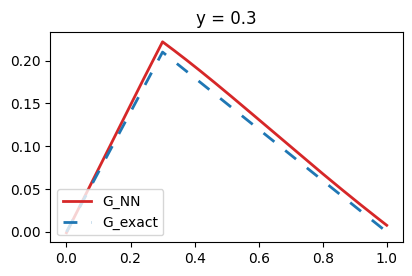

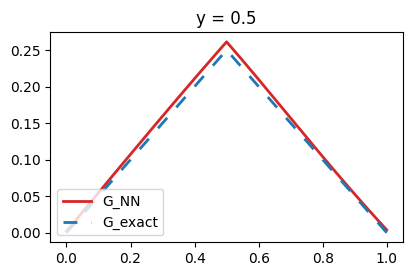

In [137]:
x = torch.linspace(x_min, x_max, steps = 1001)
y = torch.ones(x.size())

# plot the solution at y = 0.3
G_exact = Green_Exact_Line1D(x, 0.3 * y)
test_smppts = torch.cat([x.reshape(-1, 1), 0.3 * y.reshape(-1, 1)], dim=1)
test_smppts = torch.cat([test_smppts, augmented_variable(test_smppts[:, 0], test_smppts[:, 1]).reshape(-1, 1)], dim=1)
G_pred = model(test_smppts)

fig = plt.figure(figsize=(10, 6), dpi= 100)
plt.subplot(2, 2, 1)
plt.plot(x, G_pred.detach(), linewidth=2.0, label="G_NN", color="tab:red")
plt.plot(x, G_exact, linestyle='dashed', dashes=(5, 5), linewidth=2.0, label="G_exact", color="tab:blue")
plt.title('y = 0.3')
plt.legend(loc = 'lower left')

# plot the solution at y = 0.5
G_exact = Green_Exact_Line1D(x, 0.5 * y)
test_smppts = torch.cat([x.reshape(-1, 1), 0.5 * y.reshape(-1, 1)], dim=1)
test_smppts = torch.cat([test_smppts, augmented_variable(test_smppts[:, 0], test_smppts[:, 1]).reshape(-1, 1)], dim=1)
G_pred = model(test_smppts)

fig = plt.figure(figsize=(10, 6), dpi= 100)
plt.subplot(2, 2, 2)
plt.plot(x, G_pred.detach(), linewidth=2.0, label="G_NN", color="tab:red")
plt.plot(x, G_exact, linestyle='dashed', dashes=(5, 5), linewidth=2.0, label="G_exact", color="tab:blue")
plt.title('y = 0.5')
plt.legend(loc = 'lower left')